In [8]:
# importing the libraries 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score



In [9]:
# first i just opened the file to find out what it contains
f = open("desk.gcode", "r")
lines = f.readlines()
f.close()

print("total lines in file:", len(lines))
print()
print("first 20 lines of the file:")
for i in range(20):
    print(lines[i].strip())

total lines in file: 337238

first 20 lines of the file:
; Generated by Kiri:Moto 4.6.3
; Wed May 13 2026 19:37:07 GMT+0300 (Eastern European Summer Time)
; Bed left:0 right:300 top:175 bottom:0
; Bed type: fixed
; Target: Any.Generic.Marlin
; --- process ---
; antiBacklash = 0
; fdmArcEnabled = false
; fdmArcResolution = 1
; fdmArcTolerance = 0.005
; firstLayerBedTemp = 0
; firstLayerBeltBump = 0
; firstLayerBeltLead = 3
; firstLayerBeltFact = 1
; firstLayerBrim = 0
; firstLayerBrimGap = 0
; firstLayerBrimIn = 0
; firstLayerBrimTrig = 0
; firstLayerFanSpeed = 0
; firstLayerFillRate = 35


In [10]:
# the idea here i used is to go line by line and pull out the X Y Z E F numbers

class GCodeParser:
    
    def __init__(self, filename):
        self.filename = filename
        self.data = None   # will store the dataframe later
    
    def parse(self):
        
        rows = []
        layer = 0
        
        # keep track of last position
        # because gcode doesnt always repeat all values on every line
        x, y, z, e, f = 0.0, 0.0, 0.0, 0.0, 0.0
        
        file = open(self.filename, "r")
        
        for line in file:
            line = line.strip()
            if line == "":
                continue
            
            # detect layer number - cura slicer writes ;LAYER:0 ;LAYER:1 etc
            if ";LAYER:" in line.upper():
                try:
                    layer = int(line.upper().split(";LAYER:")[1])
                except:
                    pass
                continue
            if "LAYER_CHANGE" in line:
                layer += 1
                continue
            if line.startswith(";"):
                continue
             # remove comments at end of line
            if ";" in line:
                line = line[:line.index(";")]
            
            # only G1 lines have movement data
            if not line.startswith("G1"):
                continue
            
            # use regex to find numbers after X Y Z E F    
            # learned regex from the pandas week exercises
            find_x = re.search(r"X([-\d.]+)", line)         #this i used AI to find out how i extract each line for(X,Y,Z,E,F)
            find_y = re.search(r"Y([-\d.]+)", line)
            find_z = re.search(r"Z([-\d.]+)", line)
            find_e = re.search(r"E([-\d.]+)", line)
            find_f = re.search(r"F([-\d.]+)", line)
            
            if find_x: x = float(find_x.group(1))
            if find_y: y = float(find_y.group(1))
            if find_z: z = float(find_z.group(1))
            if find_e: e = float(find_e.group(1))
            if find_f: f = float(find_f.group(1))
            
            rows.append({"X": x, "Y": y, "Z": z, 
                         "E": e, "F": f, "layer": layer})
        file.close()
        self.data = pd.DataFrame(rows)
        
        # if no layer comments were found in file
        # then detect layers from Z value changes instead
        if self.data["layer"].nunique() <= 1:
            print("no layer comments found in file")
            print("detecting layers from Z height changes...")
            
            layer_col = [0]
            current_layer = 0
            for i in range(1, len(self.data)):
                if self.data["Z"].iloc[i] > self.data["Z"].iloc[i-1]:
                    current_layer += 1
                layer_col.append(current_layer)
            self.data["layer"] = layer_col
        return self.data

# creating the parser and run it
parser = GCodeParser("desk.gcode")
df = parser.parse()
print("parsing done")
print("rows:", len(df))
print("layers detected:", df["layer"].nunique())
print()
print(df.head(10))

no layer comments found in file
detecting layers from Z height changes...
parsing done
rows: 334905
layers detected: 791

          X         Y      Z        E       F  layer
0    0.0000    0.0000  0.250   0.0000   180.0      0
1    0.0000    0.0000  0.250  15.0000   200.0      0
2    0.0000    0.0000  0.250  15.0000   225.0      0
3    0.0000    0.0000  0.250  -1.5000  2400.0      0
4    0.0000    0.0000  0.255  -1.5000  4800.0      1
5  135.6750   91.5166  0.255  -1.5000  4800.0      1
6  135.6750   91.5166  0.255   1.5000  2400.0      1
7  135.6750  116.6613  0.255   1.0263  1800.0      1
8  137.0887  118.0750  0.255   0.0816  1800.0      1
9  162.9113  118.0750  0.255   1.0540  1800.0      1


In [11]:
total_layers = df["layer"].nunique()
total_moves = len(df)

# print size
x_size = round(df["X"].max() - df["X"].min(), 2)
y_size = round(df["Y"].max() - df["Y"].min(), 2)
z_size = round(df["Z"].max() - df["Z"].min(), 2)

# how much filament was used
# E value goes up as the printer pushes out filament
filament_used = round(df["E"].max() - df["E"].min(), 2)

# calculate total travel distance using numpy
# diff gives difference between each row and previous row
dx = np.diff(df["X"].values)
dy = np.diff(df["Y"].values)
dz = np.diff(df["Z"].values)

# pythagorean theorem in 3D
move_distances = np.sqrt(dx**2 + dy**2 + dz**2)
total_distance = round(np.sum(move_distances), 2)

avg_feedrate = round(df["F"].mean(), 2)

# rough time estimate = distance / speed
if avg_feedrate > 0:
    estimated_time = round(total_distance / avg_feedrate, 2)
else:
    estimated_time = 0

# average layer height
z_levels = np.sort(df["Z"].unique())
if len(z_levels) > 1:
    avg_layer_h = round(np.mean(np.diff(z_levels)), 3)
else:
    avg_layer_h = 0

print("Analysis Results")
print("layers          :", total_layers)
print("total moves     :", total_moves)
print("X size mm       :", x_size)
print("Y size mm       :", y_size)
print("Z height mm     :", z_size)
print("avg layer height:", avg_layer_h, "mm")
print("filament used   :", filament_used, "mm")
print("total distance  :", total_distance, "mm")
print("avg feedrate    :", avg_feedrate, "mm/min")
print("estimated time  :", estimated_time, "min")


Analysis Results
layers          : 791
total moves     : 334905
X size mm       : 285.08
Y size mm       : 118.47
Z height mm     : 149.75
avg layer height: 0.788 mm
filament used   : 16.5 mm
total distance  : 585980.01 mm
avg feedrate    : 2990.79 mm/min
estimated time  : 195.93 min


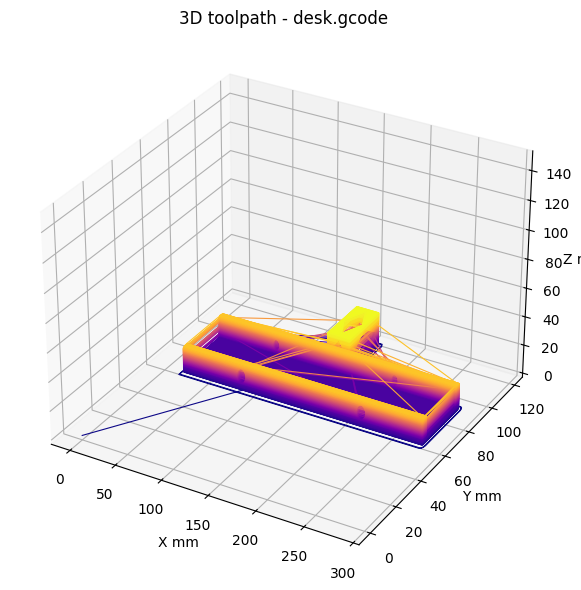

saved plot_3d.png


In [12]:
# plotting the toolpath in 3D, each layer i put different color and used plasma colormap to show different layer clearl
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

layer_list = df["layer"].unique()
colors = plt.cm.plasma(np.linspace(0, 1, len(layer_list)))

for i, lyr in enumerate(layer_list):
    one_layer = df[df["layer"] == lyr]
    ax.plot(one_layer["X"], one_layer["Y"], one_layer["Z"],
            color=colors[i], linewidth=0.8)

ax.set_xlabel("X mm")
ax.set_ylabel("Y mm")
ax.set_zlabel("Z mm")
ax.set_title("3D toolpath - desk.gcode")

plt.tight_layout()
plt.savefig("plot_3d.png", dpi=150)
plt.show()
print("saved plot_3d.png")

R2 score: -0.026
predicted filament at layer 800 : 2.1 mm


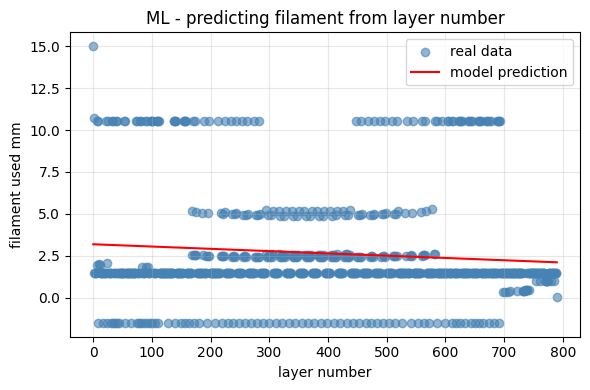

In [13]:
# group by layer and get filament used per layer(ML)
layer_stats = df.groupby("layer")["E"].max().reset_index()
layer_stats.columns = ["layer", "filament"]

# features and target
X = layer_stats[["layer"]]
y = layer_stats["filament"]

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# check accuracy
preds = model.predict(X_test)
print("R2 score:", round(r2_score(y_test, preds), 3))

# predict filament for any layer number
next_layer = pd.DataFrame([{"layer": df["layer"].max() + 10}])
predicted_filament = round(model.predict(next_layer)[0], 2)
print("predicted filament at layer", df["layer"].max() + 10, ":", predicted_filament, "mm")

# plot
plt.figure(figsize=(6,4))
plt.scatter(layer_stats["layer"], layer_stats["filament"], 
            color="steelblue", alpha=0.6, label="real data")
plt.plot(layer_stats["layer"], model.predict(layer_stats[["layer"]]), 
         color="red", label="model prediction")
plt.xlabel("layer number")
plt.ylabel("filament used mm")
plt.title("ML - predicting filament from layer number")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_ml.png", dpi=150)
plt.show()

In [14]:
# GUI part 
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

def run_gui():
    
    window = tk.Tk()
    window.title("gcode visualizer")
    window.geometry("900x600")
    
    # left side - stats
    left = tk.Frame(window, width=250, bg="#f0f0f0")
    left.pack(side="left", fill="y", padx=10, pady=10)
    left.pack_propagate(False)
    
    tk.Label(left, text="Print Stats", font=("Arial", 13, "bold"),
             bg="#f0f0f0").pack(pady=10)
    
    stats = [
        ("File",        "desk.gcode"),
        ("Layers",      str(total_layers)),
        ("Moves",       str(total_moves)),
        ("X size",      str(x_size) + " mm"),
        ("Y size",      str(y_size) + " mm"),
        ("Height",      str(z_size) + " mm"),
        ("Filament",    str(filament_used) + " mm"),
        ("Distance",    str(total_distance) + " mm"),
        ("Est. time",   str(estimated_time) + " min"),
        ("ML predict filament",  str(predicted_filament) + " mm"),
    ]
    
    for label, value in stats:
        row = tk.Frame(left, bg="#f0f0f0")
        row.pack(fill="x", padx=8, pady=3)
        tk.Label(row, text=label + ":", width=10, anchor="w",
                 bg="#f0f0f0", font=("Arial", 9)).pack(side="left")
        tk.Label(row, text=value, anchor="w",
                 bg="#f0f0f0", font=("Arial", 9, "bold")).pack(side="left")
    
    # right side -combned the 3D matplotlib plot
    right = tk.Frame(window)
    right.pack(side="right", fill="both", expand=True)
    
    fig2 = plt.Figure(figsize=(6, 5))
    ax2  = fig2.add_subplot(111, projection="3d")
    
    for i, lyr in enumerate(layer_list):
        one_layer = df[df["layer"] == lyr]
        ax2.plot(one_layer["X"], one_layer["Y"], one_layer["Z"],
                 color=colors[i], linewidth=0.8)
    
    ax2.set_title("3D toolpath")
    ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")
    
    canvas = FigureCanvasTkAgg(fig2, master=right)
    canvas.draw()
    canvas.get_tk_widget().pack(fill="both", expand=True)
    
    window.mainloop()

    
run_gui()